# LLM Football Benchmark — Analysis

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

os.makedirs("../results", exist_ok=True)

COLORS = {"groq-llama": "#6C8EBF", "groq-llama70b": "#82B366"}
LABELS = {"groq-llama": "Llama 3.1 8B", "groq-llama70b": "Llama 3.3 70B"}
MODELS = ["groq-llama", "groq-llama70b"]

plt.rcParams.update({"figure.facecolor": "#F9F9F9", "axes.facecolor": "#F9F9F9",
                     "axes.grid": True, "grid.linestyle": "--", "grid.alpha": 0.5})

## Load & merge data

In [2]:
responses = pd.read_csv("../data/responses.csv")
scores = pd.read_csv("../data/judge_scores.csv")

df = responses.merge(scores[["question_id", "model", "judge_score", "judge_explanation"]],
                     on=["question_id", "model"])

# Drop the two malformed rows where difficulty was corrupted
df = df[df["difficulty"].isin(["easy", "medium", "hard"])]

df["model_label"] = df["model"].map(LABELS)
print(f"Rows: {len(df)}")
df.head()

Rows: 304


,question_id,category,difficulty,model,response,timestamp,judge_score,judge_explanation,model_label
0,Q001,CONCEPT,easy,groq-llama,The offside rule in football is a crucial part...,2026-05-20T07:56:30.747121+00:00,5,The response provides an accurate and detailed...,Llama 3.1 8B
1,Q001,CONCEPT,easy,groq-llama,The offside rule in football is a crucial part...,2026-05-20T07:56:30.747121+00:00,6,The response provides an accurate and detailed...,Llama 3.1 8B
2,Q001,CONCEPT,easy,groq-llama,The offside rule in football is a crucial part...,2026-05-20T07:56:30.747121+00:00,5,The response provides an accurate and detailed...,Llama 3.1 8B
3,Q001,CONCEPT,easy,groq-llama70b,The offside rule in football is a regulation t...,2026-05-20T07:58:04.622342+00:00,6,The response provides an accurate and clear de...,Llama 3.3 70B
4,Q001,CONCEPT,easy,groq-llama70b,The offside rule in football is a regulation t...,2026-05-20T07:58:04.622342+00:00,6,The response provides an accurate and clear de...,Llama 3.3 70B


## 1 — Overall average score per model

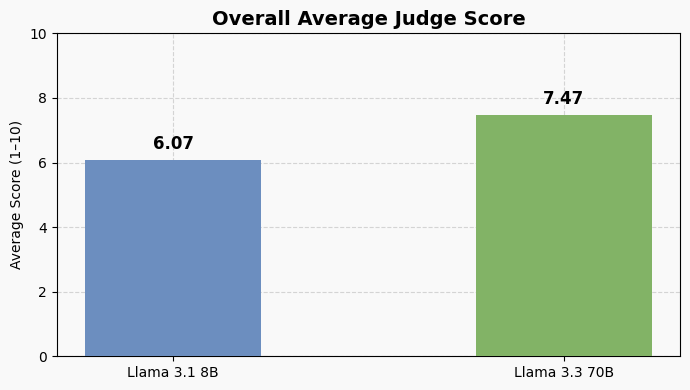

In [3]:
overall = df.groupby("model")["judge_score"].mean().reindex(MODELS)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([LABELS[m] for m in MODELS], overall.values,
              color=[COLORS[m] for m in MODELS], width=0.45, zorder=3)
ax.bar_label(bars, fmt="%.2f", padding=5, fontsize=12, fontweight="bold")
ax.set_ylim(0, 10)
ax.set_title("Overall Average Judge Score", fontsize=14, fontweight="bold")
ax.set_ylabel("Average Score (1–10)")
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("../results/01_overall.png", dpi=150, bbox_inches="tight")
plt.show()

## 2 — Score by category

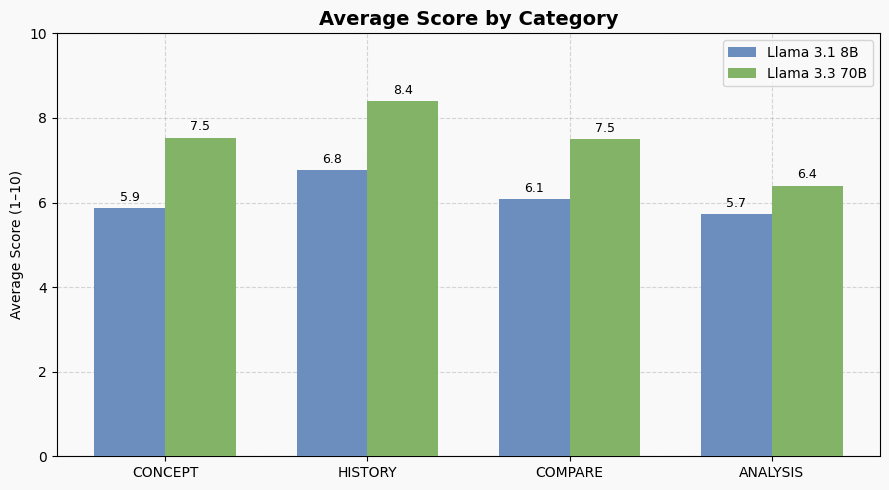

In [4]:
import numpy as np

CATEGORIES = ["CONCEPT", "HISTORY", "COMPARE", "ANALYSIS"]
cat_pivot = (df.groupby(["model", "category"])["judge_score"]
               .mean()
               .unstack("category")
               .reindex(MODELS)[CATEGORIES])

x = np.arange(len(CATEGORIES))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
for i, model in enumerate(MODELS):
    vals = cat_pivot.loc[model]
    bars = ax.bar(x + (i - 0.5) * width, vals, width,
                  label=LABELS[model], color=COLORS[model], zorder=3)
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(CATEGORIES)
ax.set_ylim(0, 10)
ax.set_title("Average Score by Category", fontsize=14, fontweight="bold")
ax.set_ylabel("Average Score (1–10)")
ax.legend()
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("../results/02_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

## 3 — Score by difficulty

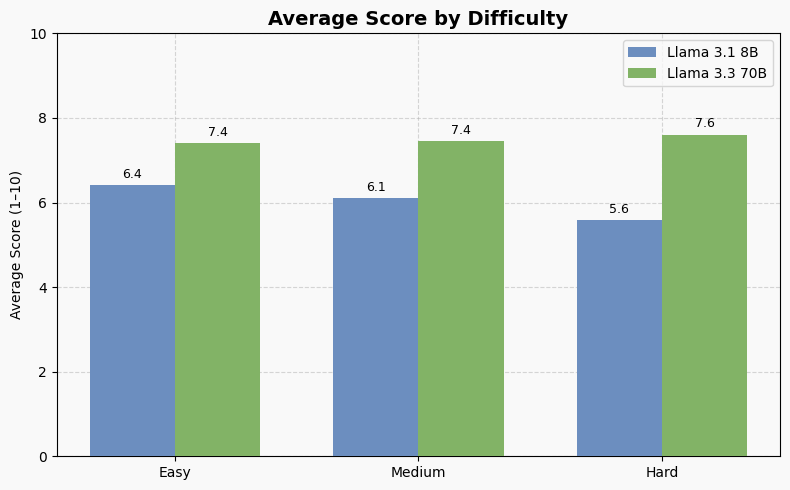

In [5]:
DIFFICULTIES = ["easy", "medium", "hard"]
diff_pivot = (df.groupby(["model", "difficulty"])["judge_score"]
                .mean()
                .unstack("difficulty")
                .reindex(MODELS)[DIFFICULTIES])

x = np.arange(len(DIFFICULTIES))

fig, ax = plt.subplots(figsize=(8, 5))
for i, model in enumerate(MODELS):
    vals = diff_pivot.loc[model]
    bars = ax.bar(x + (i - 0.5) * width, vals, width,
                  label=LABELS[model], color=COLORS[model], zorder=3)
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([d.capitalize() for d in DIFFICULTIES])
ax.set_ylim(0, 10)
ax.set_title("Average Score by Difficulty", fontsize=14, fontweight="bold")
ax.set_ylabel("Average Score (1–10)")
ax.legend()
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("../results/03_by_difficulty.png", dpi=150, bbox_inches="tight")
plt.show()

## 4 — Score distribution

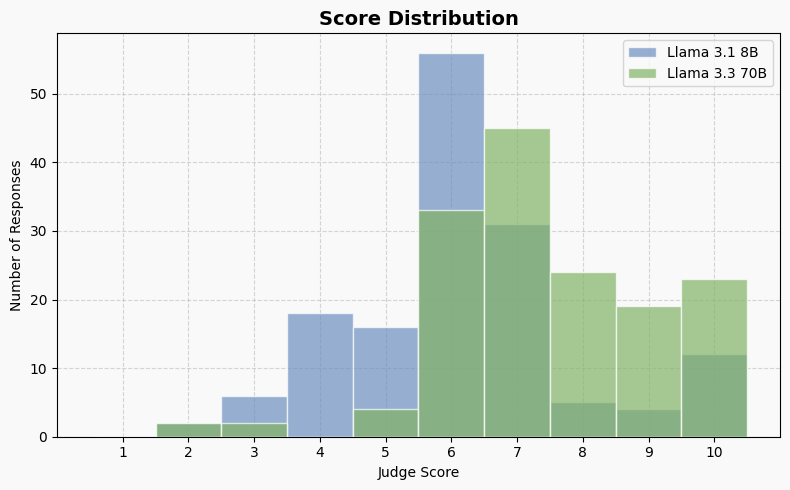

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
bins = range(1, 12)
for model in MODELS:
    scores = df[df["model"] == model]["judge_score"]
    ax.hist(scores, bins=bins, alpha=0.7, label=LABELS[model],
            color=COLORS[model], edgecolor="white", align="left", zorder=3)

ax.set_xticks(range(1, 11))
ax.set_title("Score Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Judge Score")
ax.set_ylabel("Number of Responses")
ax.legend()
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("../results/04_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 5 — Summary

In [7]:
overall_means = df.groupby("model")["judge_score"].mean()
best_overall = LABELS[overall_means.idxmax()]

cat_means = df.groupby(["category", "model"])["judge_score"].mean().unstack("model")
best_per_cat = {cat: LABELS[row.idxmax()] for cat, row in cat_means.iterrows()}

gaps = (df.groupby(["category", "model"])["judge_score"]
          .mean()
          .unstack("model")
          .assign(gap=lambda d: (d["groq-llama70b"] - d["groq-llama"]).abs()))
biggest_gap_cat = gaps["gap"].idxmax()
biggest_gap_val = gaps["gap"].max()

print("=" * 50)
print(f"  Best model overall:       {best_overall}")
print(f"    Llama 3.1 8B  avg:      {overall_means['groq-llama']:.2f}")
print(f"    Llama 3.3 70B avg:      {overall_means['groq-llama70b']:.2f}")
print()
print("  Best model per category:")
for cat, winner in best_per_cat.items():
    m1, m2 = cat_means.loc[cat, "groq-llama"], cat_means.loc[cat, "groq-llama70b"]
    print(f"    {cat:10s}  →  {winner}  ({m1:.1f} vs {m2:.1f})")
print()
print(f"  Biggest score gap:        {biggest_gap_cat}  ({biggest_gap_val:.2f} pts)")
print("=" * 50)

  Best model overall:       Llama 3.3 70B
    Llama 3.1 8B  avg:      6.07
    Llama 3.3 70B avg:      7.47

  Best model per category:
    ANALYSIS    →  Llama 3.3 70B  (5.7 vs 6.4)
    COMPARE     →  Llama 3.3 70B  (6.1 vs 7.5)
    CONCEPT     →  Llama 3.3 70B  (5.9 vs 7.5)
    HISTORY     →  Llama 3.3 70B  (6.8 vs 8.4)

  Biggest score gap:        CONCEPT  (1.67 pts)


## RAG vs No-RAG Comparison

In [14]:

scores_rag = pd.read_csv("../data/judge_scores_rag.csv")

comparison = pd.DataFrame({
    "model":      ["groq-llama", "groq-llama70b", "groq-llama-rag", "groq-llama70b-rag"],
    "label":      ["Llama 3.1 8B\n(No RAG)", "Llama 3.3 70B\n(No RAG)",
                   "Llama 3.1 8B\n(RAG)", "Llama 3.3 70B\n(RAG)"],
    "avg_score":  [6.01, 7.43, 5.76, 6.60],
    "rag":        [False, False, True, True],
    "base_model": ["groq-llama", "groq-llama70b", "groq-llama", "groq-llama70b"],
})
comparison


,model,label,avg_score,rag,base_model
0,groq-llama,Llama 3.1 8B\n(No RAG),6.01,False,groq-llama
1,groq-llama70b,Llama 3.3 70B\n(No RAG),7.43,False,groq-llama70b
2,groq-llama-rag,Llama 3.1 8B\n(RAG),5.76,True,groq-llama
3,groq-llama70b-rag,Llama 3.3 70B\n(RAG),6.60,True,groq-llama70b


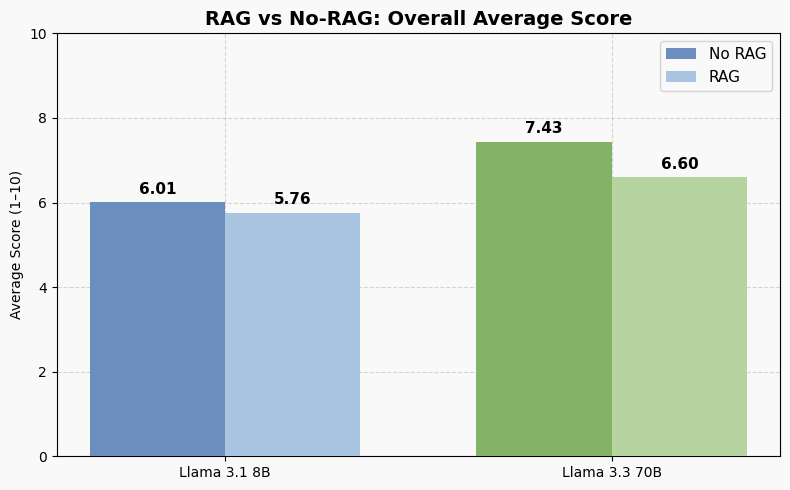

In [15]:

# Chart 5 — Overall RAG vs No-RAG comparison
fig, ax = plt.subplots(figsize=(8, 5))

groups = ["Llama 3.1 8B", "Llama 3.3 70B"]
no_rag_scores = [6.01, 7.43]
rag_scores    = [5.76, 6.60]

x = np.arange(len(groups))
w = 0.35

bars1 = ax.bar(x - w / 2, no_rag_scores, w, label="No RAG",
               color=["#6C8EBF", "#82B366"], zorder=3)
bars2 = ax.bar(x + w / 2, rag_scores, w, label="RAG",
               color=["#A8C4E0", "#B5D4A0"], zorder=3)

ax.bar_label(bars1, fmt="%.2f", padding=4, fontsize=11, fontweight="bold")
ax.bar_label(bars2, fmt="%.2f", padding=4, fontsize=11, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_ylim(0, 10)
ax.set_title("RAG vs No-RAG: Overall Average Score", fontsize=14, fontweight="bold")
ax.set_ylabel("Average Score (1–10)")
ax.legend(fontsize=11)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("../results/05_rag_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


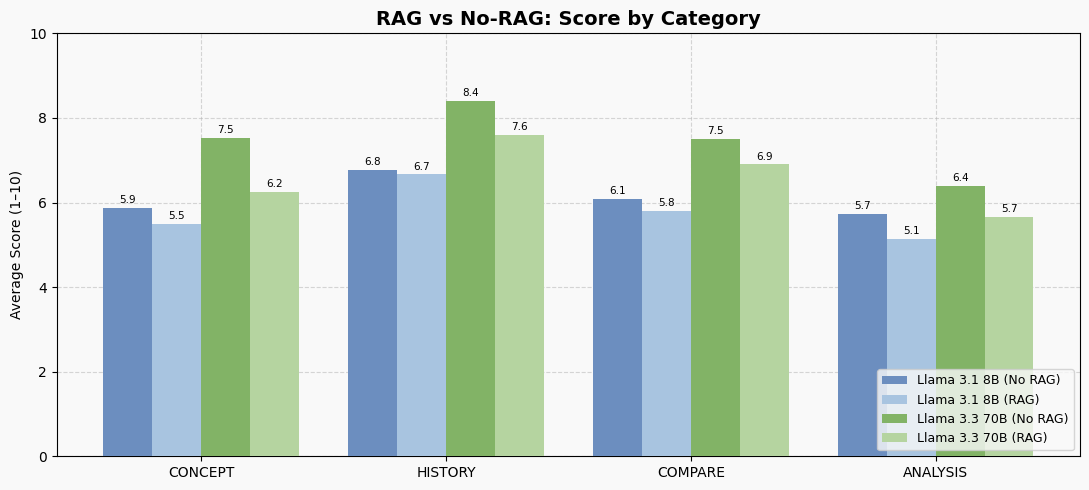

In [16]:

# Chart 6 — RAG vs No-RAG by category
no_rag_cat_model = (df[df["model"].isin(["groq-llama", "groq-llama70b"])]
                    .groupby(["category", "model"])["judge_score"].mean().unstack("model"))
rag_cat_model = (scores_rag.groupby(["category", "model"])["judge_score"]
                 .mean().unstack("model")
                 .rename(columns={"groq-llama-rag": "groq-llama", "groq-llama70b-rag": "groq-llama70b"}))

x = np.arange(len(CATEGORIES))
w = 0.2

RAG_COLORS = {
    "groq-llama":    ("#6C8EBF", "#A8C4E0"),
    "groq-llama70b": ("#82B366", "#B5D4A0"),
}

fig, ax = plt.subplots(figsize=(11, 5))
offsets = [-1.5, -0.5, 0.5, 1.5]
series = [
    ("groq-llama",    False, "Llama 3.1 8B (No RAG)"),
    ("groq-llama-rag", False, "Llama 3.1 8B (RAG)"),
    ("groq-llama70b", False, "Llama 3.3 70B (No RAG)"),
    ("groq-llama70b-rag", False, "Llama 3.3 70B (RAG)"),
]

for idx, (base, _, label) in enumerate(series):
    is_rag = "rag" in base
    base_key = base.replace("-rag", "")
    color = RAG_COLORS[base_key][1 if is_rag else 0]
    source = rag_cat_model if is_rag else no_rag_cat_model
    col = base_key
    vals = [source.loc[cat, col] if cat in source.index else 0 for cat in CATEGORIES]
    bars = ax.bar(x + offsets[idx] * w, vals, w, label=label, color=color, zorder=3)
    ax.bar_label(bars, fmt="%.1f", padding=2, fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(CATEGORIES)
ax.set_ylim(0, 10)
ax.set_title("RAG vs No-RAG: Score by Category", fontsize=14, fontweight="bold")
ax.set_ylabel("Average Score (1–10)")
ax.legend(loc="lower right", fontsize=9)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("../results/06_rag_by_category.png", dpi=150, bbox_inches="tight")
plt.show()


In [17]:

# Summary
rag_diff_8b  = 5.76 - 6.01   # -0.25
rag_diff_70b = 6.60 - 7.43   # -0.83

no_rag_cat = (df[df["model"].isin(["groq-llama", "groq-llama70b"])]
              .groupby("category")["judge_score"].mean())
rag_cat = scores_rag.groupby("category")["judge_score"].mean()
cat_diff = rag_cat - no_rag_cat
most_affected_cat = cat_diff.abs().idxmax()
most_affected_dir = "improved" if cat_diff[most_affected_cat] > 0 else "hurt"

better_model = "Llama 3.1 8B" if abs(rag_diff_8b) < abs(rag_diff_70b) else "Llama 3.3 70B"

print("=" * 52)
print("  RAG vs No-RAG Summary")
print("=" * 52)
overall_verdict = "hurt" if (rag_diff_8b < 0 and rag_diff_70b < 0) else "improved"
print(f"  Did RAG improve or hurt performance?")
print(f"    → RAG {overall_verdict} both models")
print(f"      Llama 3.1 8B:  {6.01:.2f} → {5.76:.2f}  ({rag_diff_8b:+.2f})")
print(f"      Llama 3.3 70B: {7.43:.2f} → {6.60:.2f}  ({rag_diff_70b:+.2f})")
print()
print(f"  Which category was most affected?")
print(f"    → {most_affected_cat}  ({cat_diff[most_affected_cat]:+.2f} pts, {most_affected_dir})")
print()
print(f"  Which model handled RAG better?")
print(f"    → {better_model} (smaller performance drop)")
print("=" * 52)


  RAG vs No-RAG Summary
  Did RAG improve or hurt performance?
    → RAG hurt both models
      Llama 3.1 8B:  6.01 → 5.76  (-0.25)
      Llama 3.3 70B: 7.43 → 6.60  (-0.83)

  Which category was most affected?
    → CONCEPT  (-0.83 pts, hurt)

  Which model handled RAG better?
    → Llama 3.1 8B (smaller performance drop)
